# Developer Salary Prediction — ML1 Regression Project

**Task:** Predict annual compensation (annual.pay.usd) of software developers using ML algorithms from the ML1 course.

**Evaluation metric:** RMSE (Root Mean Squared Error)

**My approach:**
1. EDA — understand distributions, missing values, outliers
2. Preprocessing & Feature Engineering — encoding, imputation, scaling, interactions
3. Feature Selection — correlation filter, variance threshold, mutual information
4. Modeling — compare ≥3 algorithms: OLS, Ridge, Lasso, Elastic Net, KNN, SVR
5. Hyperparameter Tuning — CV-based optimization on train, evaluate on validation
6. Final Evaluation — unbiased RMSE on held-out internal test set
7. Submission — retrain on all data, predict on competition test set

In [ ]:
import os

Working directory: /Users/kamillatadjibaeva/Documents/UNI/MASTERS/SEM2/ML1/Project/Developer-Salary-Prediction---Regression


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_regression, VarianceThreshold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv("data/train.csv")
print(f"Training data: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Training data: 2512 rows, 41 columns


,annual.pay.usd,region,age.group,employment.type,work.location,education,is.dev.professional,coding.years.total,coding.years.professional,experience.years,dev.role,company.size,people.manager,industry,tech.purchase.influence,build.vs.buy,side.coding,how.learned.coding,prog.languages,databases,cloud.platforms,web.frameworks,other.tech,dev.tools,dev.environments,personal.os,work.os,project.mgmt.tools,comm.tools,ai.search.tools,ai.tools.used,uses.ai,ai.sentiment,ai.trust,ai.complex.rating,ai.job.threat,daily.search.time,daily.answer.time,cloud.hosting,first.help.source,job.satisfaction
0,44529.0,R11,35-44,Freelance/Self-employed,In-person,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,29.0,16.0,17.0,"Developer, desktop or enterprise applications",2 to 9 employees,Individual contributor,Computer Systems Design and Services,I have a great deal of influence,Is ready-to-go but also customizable for growt...,Bootstrapping a business;Freelance/contract wo...,Books / Physical media;Colleague;Friend or fam...,C++;Dart;Delphi;HTML/CSS;JavaScript;PHP;SQL,Cloud Firestore;Elasticsearch;PostgreSQL;Redis...,NaN,NaN,Flutter;OpenGL,APT;Chocolatey;Make;Webpack;npm,"Android Studio;Netbeans;Rad Studio (Delphi, C+...",Debian;Other Linux-based,Debian;Other Linux-based,NaN,Whatsapp,ChatGPT;Google Gemini;WolframAlpha,Debugging and getting help;Learning about a co...,Yes,Indifferent,Somewhat trust,Very poor at handling complex tasks,No,60-120 minutes a day,15-30 minutes a day,Hybrid (on-prem and cloud),Traditional public search engine,7.0
1,82086.0,R05,35-44,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,17.0,14.0,13.0,"Developer, back-end",20 to 99 employees,Individual contributor,"Internet, Telecomm or Information Services",I have little or no influence,Is ready-to-go but also customizable for growt...,Contribute to open-source projects;Hobby,Books / Physical media;Colleague;Online Course...,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Dynamodb;Elasticsearch;H2;MariaDB;MySQL;Postgr...,Amazon Web Services (AWS);OpenShift,AngularJS;Node.js;Spring Boot;jQuery,Quarkus;RabbitMQ;Spring Framework,APT;Ansible;Ant;Docker;Gradle;Homebrew;Kuberne...,IntelliJ IDEA;Vim;Visual Studio Code,Ubuntu,Ubuntu,Confluence;Jira;Miro,Google Meet;Microsoft Teams;Slack,ChatGPT,NaN,"No, and I don't plan to",NaN,NaN,NaN,NaN,30-60 minutes a day,Less than 15 minutes a day,Cloud only (single or multi-cloud),Traditional public search engine,6.0
2,14223.0,R17,18-24,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,4.0,0.0,1.0,"Developer, full-stack",100 to 499 employees,NaN,NaN,I have some influence,Is set up to be customized and needs to be eng...,Freelance/contract work;Professional developme...,On the job training;Online Courses or Certific...,HTML/CSS;JavaScript;Python;TypeScript,Firebase Realtime Database;MongoDB;MySQL;Postg...,Amazon Web Services (AWS);Firebase,Django;FastAPI;Next.js;React;Vue.js,React Native,Docker;Gradle;Make;Pip;Vite;Webpack;Yarn;npm,Android Studio;PyCharm;WebStorm,Windows,Other (please specify):,Confluence;Jira,Slack;Telegram;Zoom,ChatGPT;GitHub Copilot,NaN,Yes,Very favorable,Neither trust nor distrust,NaN,I'm not sure,NaN,NaN,NaN,NaN,10.0


## Part 1: Exploratory Data Analysis

In [3]:
# Basic info & missing values
print("Data Types & Missing Values:")
print(df.dtypes.value_counts(), "\n")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(missing_summary[missing_summary["missing"] > 0].sort_values("pct", ascending=False).to_string())
print(f"\nTotal columns with missing values: {(missing > 0).sum()} / {df.shape[1]}")

Data Types & Missing Values:
str        36
float64     5
Name: count, dtype: int64 

                           missing   pct
cloud.hosting                  900  35.8
daily.answer.time              888  35.4
daily.search.time              886  35.3
first.help.source              883  35.2
industry                       879  35.0
job.satisfaction               867  34.5
experience.years               863  34.4
people.manager                 859  34.2
other.tech                     853  34.0
ai.tools.used                  850  33.8
ai.complex.rating              781  31.1
ai.trust                       771  30.7
web.frameworks                 581  23.1
cloud.platforms                554  22.1
ai.search.tools                485  19.3
ai.sentiment                   444  17.7
ai.job.threat                  443  17.6
databases                      306  12.2
project.mgmt.tools             199   7.9
dev.tools                      159   6.3
build.vs.buy                   157   6.2
work.os      

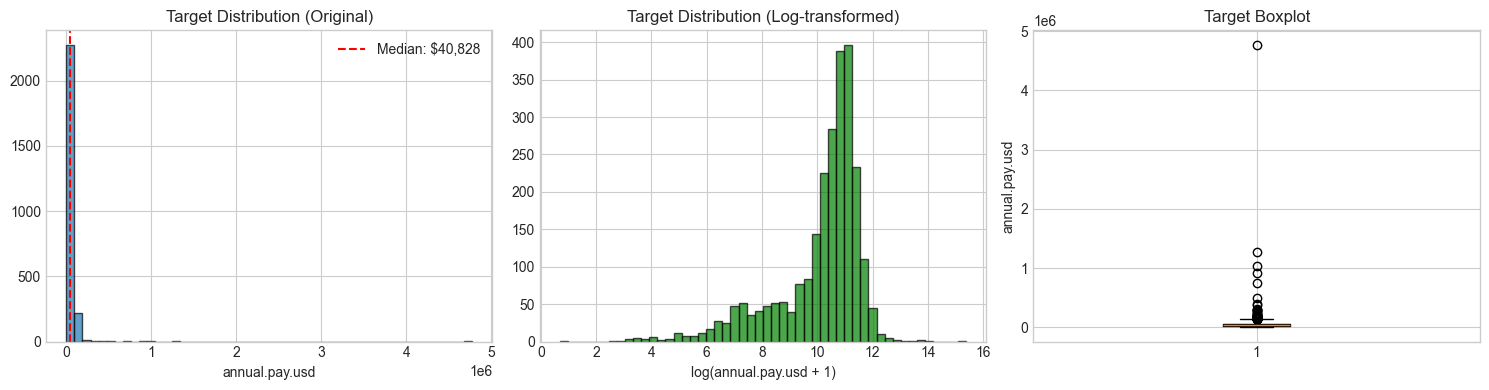

Target Variable Statistics:
count    2.512000e+03
mean     4.971296e+04
std      1.096162e+05
min      1.000000e+00
25%      1.621675e+04
50%      4.082850e+04
75%      6.558925e+04
max      4.773360e+06
Name: annual.pay.usd, dtype: float64

1st percentile: $98
5th percentile: $834
95th percentile: $118,863
99th percentile: $177,388

Rows with salary < $300: 57
Skewness: 33.13


In [4]:
# Target variable analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['annual.pay.usd'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title("Target Distribution (Original)")
axes[0].set_xlabel("annual.pay.usd")
axes[0].axvline(df['annual.pay.usd'].median(), color='r', linestyle='--', label=f"Median: ${df['annual.pay.usd'].median():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['annual.pay.usd']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title("Target Distribution (Log-transformed)")
axes[1].set_xlabel("log(annual.pay.usd + 1)")

axes[2].boxplot(df['annual.pay.usd'], vert=True)
axes[2].set_title("Target Boxplot")
axes[2].set_ylabel("annual.pay.usd")

plt.tight_layout()
plt.show()

# Key percentiles
print("Target Variable Statistics:")
print(df['annual.pay.usd'].describe())
print(f"\n1st percentile: ${df['annual.pay.usd'].quantile(0.01):,.0f}")
print(f"5th percentile: ${df['annual.pay.usd'].quantile(0.05):,.0f}")
print(f"95th percentile: ${df['annual.pay.usd'].quantile(0.95):,.0f}")
print(f"99th percentile: ${df['annual.pay.usd'].quantile(0.99):,.0f}")
print(f"\nRows with salary < $300: {(df['annual.pay.usd'] < 300).sum()}")
print(f"Skewness: {df['annual.pay.usd'].skew():.2f}")

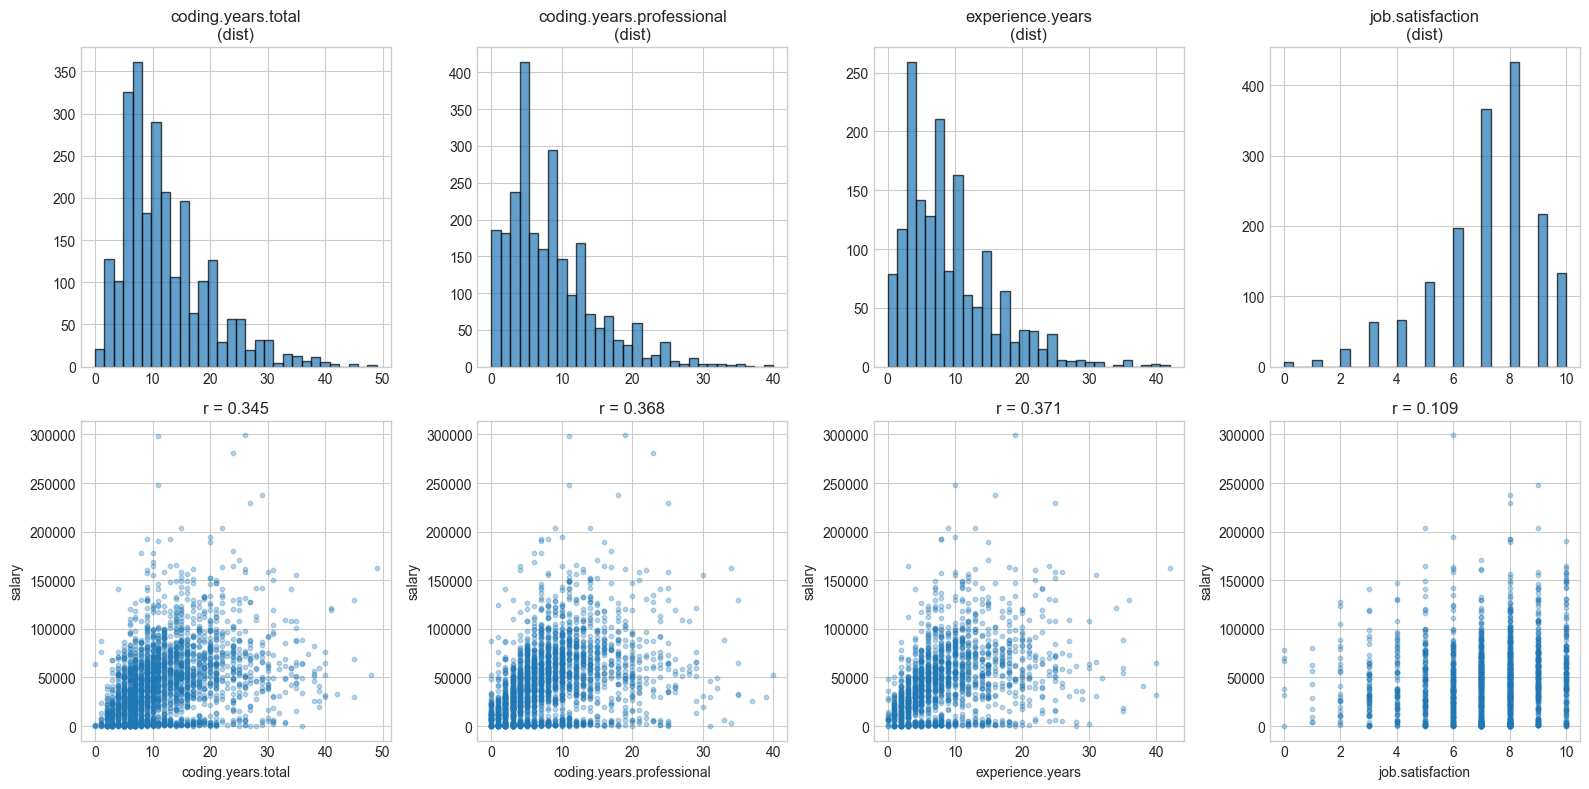


Correlations between numeric features (salary < $300K):
                           coding.years.total  coding.years.professional  experience.years  job.satisfaction  annual.pay.usd
coding.years.total                      1.000                      0.885             0.831             0.100           0.345
coding.years.professional               0.885                      1.000             0.897             0.121           0.368
experience.years                        0.831                      0.897             1.000             0.127           0.371
job.satisfaction                        0.100                      0.121             0.127             1.000           0.109
annual.pay.usd                          0.345                      0.368             0.371             0.109           1.000


In [5]:
# Numeric features: distributions and correlations with target (filtered: salary < $500K)
numeric_cols = ['coding.years.total', 'coding.years.professional', 'experience.years', 'job.satisfaction']
df_filt = df[df['annual.pay.usd'] < 300_000]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    # Distribution
    axes[0, i].hist(df_filt[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f"{col}\n(dist)")
    # Scatter vs target
    axes[1, i].scatter(df_filt[col], df_filt['annual.pay.usd'], alpha=0.3, s=10)
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel("salary")
    corr = df_filt[col].corr(df_filt['annual.pay.usd'])
    axes[1, i].set_title(f"r = {corr:.3f}")
plt.tight_layout()
plt.show()

# Correlation matrix for numeric features
print("\nCorrelations between numeric features (salary < $300K):")
corr_matrix = df_filt[numeric_cols + ['annual.pay.usd']].corr()
print(corr_matrix.round(3).to_string())

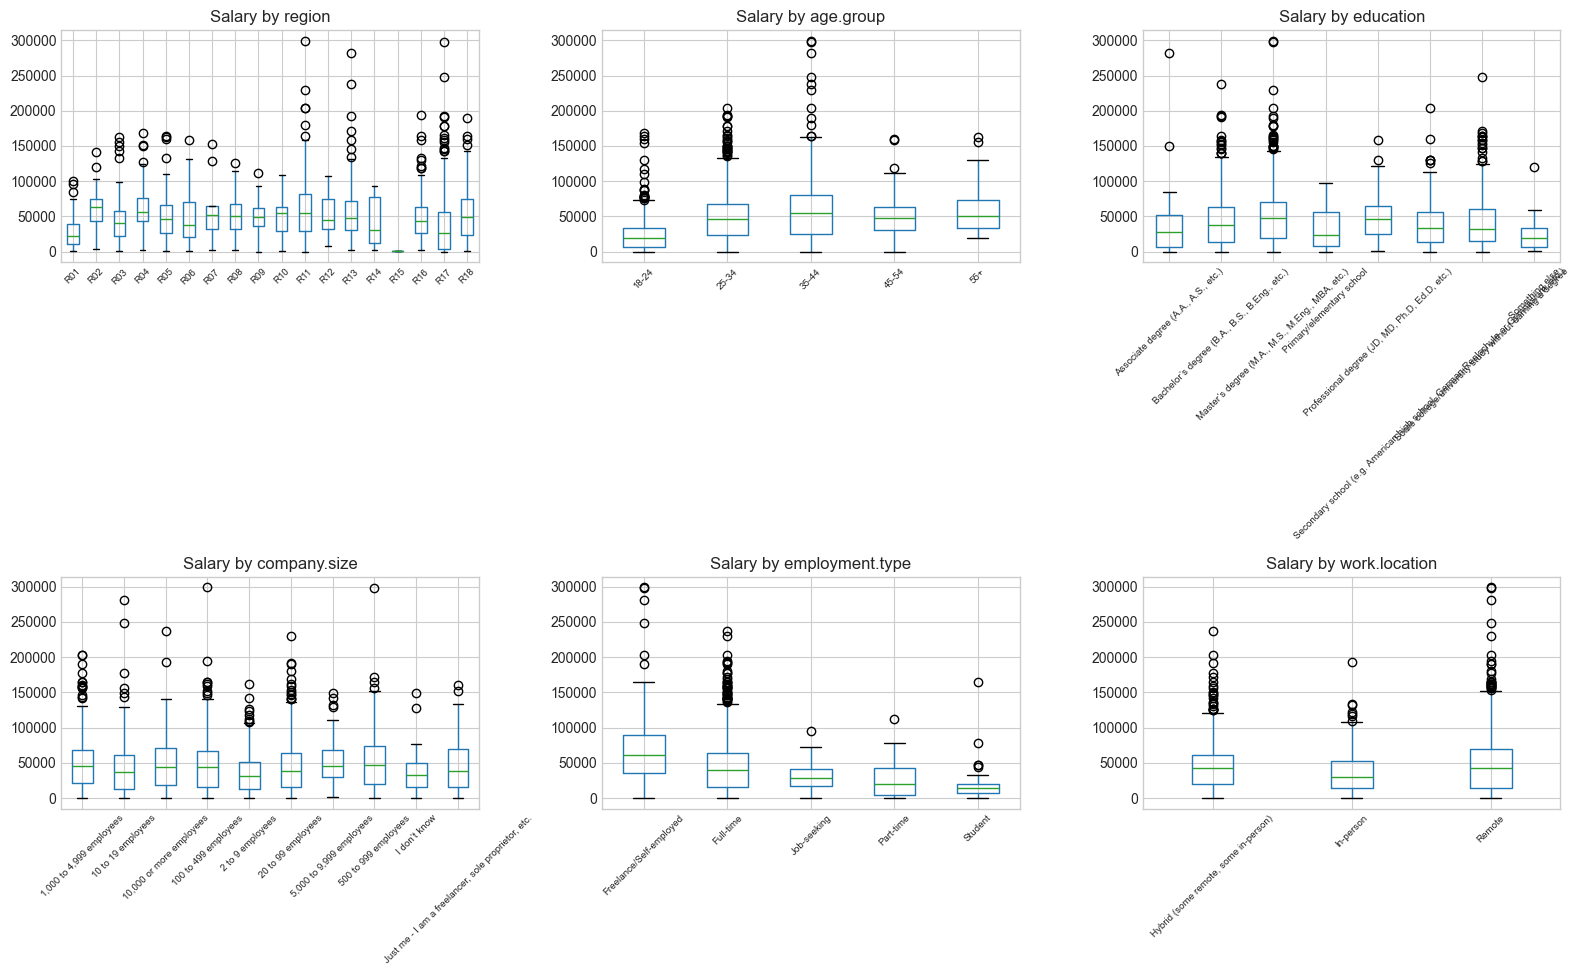

In [6]:
# Salary by key categorical features (filtered: salary < $300K)
df_filt_cat = df[df['annual.pay.usd'] < 300_000]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cat_features = ['region', 'age.group', 'education', 'company.size', 'employment.type', 'work.location']
for i, col in enumerate(cat_features):
    ax = axes[i // 3, i % 3]
    df_filt_cat.boxplot(column='annual.pay.usd', by=col, ax=ax, vert=True)
    ax.set_title(f"Salary by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.suptitle("")
plt.tight_layout()
plt.show()

In [7]:
# Multi-select columns: cardinality and top values
multi_select_cols = ['prog.languages', 'databases', 'cloud.platforms', 'web.frameworks',
                     'other.tech', 'dev.tools', 'dev.environments', 'personal.os',
                     'work.os', 'project.mgmt.tools', 'comm.tools', 'ai.search.tools',
                     'ai.tools.used', 'how.learned.coding', 'side.coding']

print("Multi-select columns")
for col in multi_select_cols:
    unique_vals = df[col].dropna().str.split(';').explode().str.strip().nunique()
    avg_count = df[col].dropna().str.split(';').apply(len).mean()
    print(f"{col:25s} | {unique_vals:3d} unique values")

Multi-select columns
prog.languages            |  40 unique values
databases                 |  29 unique values
cloud.platforms           |  25 unique values
web.frameworks            |  34 unique values
other.tech                |  37 unique values
dev.tools                 |  34 unique values
dev.environments          |  33 unique values
personal.os               |  17 unique values
work.os                   |  14 unique values
project.mgmt.tools        |  24 unique values
comm.tools                |  18 unique values
ai.search.tools           |  16 unique values
ai.tools.used             |  12 unique values
how.learned.coding        |   9 unique values
side.coding               |   8 unique values


## Part 2: Preprocessing & Feature Engineering

### Data Cleaning & Split

**Outlier handling (target):** Rows with annual.pay.usd < 1000 are clear data errors (a $1 salary is not real) — I remove these before splitting.

**Three-way split:** I split into train (60%), validation (20%), internal test (20%):
- **Train** — fit models and run CV
- **Validation** — tune hyperparameters, compare algorithms
- **Internal test** — touched ONCE at the end for unbiased RMSE estimate to report

**No additional target filtering:** I rely on log1p transformation to compress the right tail and on SVR's epsilon-insensitive zone for robustness to high earners. Aggressive IQR filtering would remove high earners from training, preventing the model from predicting them on unfiltered test/Kaggle data.

In [8]:
# Remove clear data errors only (before splitting)
print(f"Rows before cleaning: {len(df)}")
df = df[df['annual.pay.usd'] >= 1000].copy()
print(f"Rows after removing salary < $1000: {len(df)}")

y = df['annual.pay.usd']
X = df.drop(columns=['annual.pay.usd'])

# First split: 80% train+val vs 20% internal test
X_temp, X_test_internal, y_temp, y_test_internal = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)


Rows before cleaning: 2512
Rows after removing salary < $1000: 2362


### Target Transformation

The salary distribution is heavily right-skewed (skewness > 2). I apply log1p transformation to:
1. Reduce the influence of extreme high earners on RMSE
2. Make the distribution more Gaussian-like (beneficial for linear models)

I do NOT cap the target — SVR is robust to outliers, and capping removes signal about high earners that helps predict them on test data.

I evaluate in original dollars by inverting with expm1.

In [9]:
# Log-transform target 
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_internal_log = np.log1p(y_test_internal)

print(f"Target range (log): [{y_train_log.min()}, {y_train_log.max()}]")

Target range (log): [6.920671504248683, 15.378561226901253]


### Domain Knowledge Feature Filter and imputation of missing values where needed

I removed columns that have no logical connection to annual salary:

**No salary signal / leakage:**
- first.help.source, personal.os, comm.tools, dev.environments — reflect personal preferences/habits, not compensation drivers
- ai.sentiment, ai.trust, ai.complex.rating, ai.job.threat — subjective AI opinions, not salary predictors
- how.learned.coding — redundant with education feature
- side.coding — hobby/open-source activity doesn't directly determine full-time pay
- job.satisfaction — **target leakage risk**: satisfaction is partly *caused by* salary

**Dropped due to high missing + weak signal:**
- cloud.hosting (35.8%), daily.search.time (35.3%), people.manager (34.2%) — high missing with weak/no salary signal

**Kept despite high missing because of big effect on salary:**
- experience.years (34.4% missing) — direct experience measure. I add a MissingIndicator and impute from coding.years.professional (r>0.7)
- industry (35.0% missing) — finance/tech/healthcare pay very differently. I add a "Missing" category
- daily.answer.time (35.4% missing) — time spent helping others may correlate with seniority/expertise. I add ordinal encoding with "Missing" = -1

**Strategy:** For these kept columns, I use a **hybrid approach** — add explicit missing indicators (so the model can learn if "missing" itself is informative), then impute the values.

In [10]:
drop_cols = [
    # No salary signal / leakage
    'first.help.source', 'personal.os', 'comm.tools', 'dev.environments',
    'ai.sentiment', 'ai.trust', 'ai.complex.rating', 'ai.job.threat',
    'how.learned.coding', 'side.coding', 'job.satisfaction',
    # High missing + weak signal
    'cloud.hosting', 'daily.search.time', 'people.manager',
]

X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in drop_cols if c in X_val.columns])
X_test_internal = X_test_internal.drop(columns=[c for c in drop_cols if c in X_test_internal.columns])

# creating missing categories
for df_x in [X_train, X_val, X_test_internal]:
    df_x['experience_missing'] = df_x['experience.years'].isnull().astype(int)
    df_x['industry_missing'] = df_x['industry'].isnull().astype(int)
    df_x['daily_answer_missing'] = df_x['daily.answer.time'].isnull().astype(int)

for df_x in [X_train, X_val, X_test_internal]:
    df_x['industry'] = df_x['industry'].fillna('Missing')

# ordinary variable
time_order = {
    "Less than 15 minutes a day": 0, "15-30 minutes a day": 1,
    "30-60 minutes a day": 2, "60-120 minutes a day": 3,
    "Over 120 minutes a day": 4
}
for df_x in [X_train, X_val, X_test_internal]:
    df_x['daily.answer.time'] = df_x['daily.answer.time'].map(time_order).fillna(-1)

# experience.years: impute from coding.years.professional + coding.years.total
from sklearn.linear_model import LinearRegression as LR_imp
exp_predictors = ['coding.years.professional', 'coding.years.total']
mask_exp_complete = (X_train['experience.years'].notna() &
                    X_train['coding.years.professional'].notna() &
                    X_train['coding.years.total'].notna())
exp_imputer = LR_imp()
exp_imputer.fit(
    X_train.loc[mask_exp_complete, exp_predictors],
    X_train.loc[mask_exp_complete, 'experience.years']
)

for df_x in [X_train, X_val, X_test_internal]:
    # Impute where experience is missing but both coding columns are available
    missing_exp = (df_x['experience.years'].isnull() &
                   df_x['coding.years.professional'].notna() &
                   df_x['coding.years.total'].notna())
    if missing_exp.any():
        df_x.loc[missing_exp, 'experience.years'] = exp_imputer.predict(
            df_x.loc[missing_exp, exp_predictors]
        )

    # Remaining missing: fill with median
    still_missing = df_x['experience.years'].isnull()
    if still_missing.any():
        df_x.loc[still_missing, 'experience.years'] = X_train.loc[mask_exp_complete, 'experience.years'].median()

### Region Target Encoding

Region is the strongest salary predictor — developers in North America earn 3-5× more than in South Asia. Standard one-hot encoding creates many sparse columns and loses the ordinal salary relationship between regions.

**Target mean encoding** replaces each region with the mean log-salary of that region:
- On training data: I use 5-fold leave-one-out (LOO) encoding to prevent target leakage
- On validation/test data: full training set means as lookup

This gives the model a single, highly informative numeric feature instead of 10+ sparse dummies.

In [11]:
global_mean_log = y_train_log.mean()

region_train = X_train['region'].copy()
region_val = X_val['region'].copy()
region_test = X_test_internal['region'].copy()

region_enc_train = pd.Series(index=X_train.index, dtype=float)
kf_enc = KFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, vl_idx in kf_enc.split(X_train):
    fold_means = y_train_log.iloc[tr_idx].groupby(region_train.iloc[tr_idx]).mean()
    region_enc_train.iloc[vl_idx] = region_train.iloc[vl_idx].map(fold_means).fillna(global_mean_log)

# For val/test: use full train region means
full_region_means = y_train_log.groupby(region_train).mean()
region_enc_val = region_val.map(full_region_means).fillna(global_mean_log)
region_enc_test = region_test.map(full_region_means).fillna(global_mean_log)

# Add encoded feature and drop original
X_train['region_target_enc'] = region_enc_train.values
X_val['region_target_enc'] = region_enc_val.values
X_test_internal['region_target_enc'] = region_enc_test.values

X_train = X_train.drop(columns=['region'])
X_val = X_val.drop(columns=['region'])
X_test_internal = X_test_internal.drop(columns=['region'])


print(f"Region means (top 5):")
for region, mean_val in full_region_means.sort_values(ascending=False).head().items():
    print(f"{region}: {mean_val} ({np.expm1(mean_val)})")

Region means (top 5):
R10: 10.91793339083079 (55155.6937493142)
R02: 10.837809880889203 (50908.757363152756)
R11: 10.778349503012675 (47969.88306466759)
R04: 10.766588708408502 (47409.011971611464)
R12: 10.721827177946034 (45333.66170541177)


### Feature Encoding

My encoding strategy:
- **Region**  already target-encoded above (mean log-salary per region)
- **Ordinal features**  integer mapping (preserves natural order)
- **Binary features**  0/1 encoding
- **Multi-select columns (salary-relevant)**: top-10 binary indicators + count feature
- **Multi-select columns (less relevant)**: count only
- **Nominal categoricals**: one-hot encoding with drop_first=True

In [12]:
def encode_all_features(X_train, X_val, X_test_internal):
    """Apply all encoding transformations. Fit on train only, transform all splits."""
    datasets = [X_train, X_val, X_test_internal]
    
    #Ordinal Encoding
    age_order = {"18-24": 0, "25-34": 1, "35-44": 2, "45-54": 3, "55+": 4}
    edu_order = {
        "Primary/elementary school": 0,
        "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
        "Some college/university study without earning a degree": 2,
        "Associate degree (A.A., A.S., etc.)": 3,
        "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": 4,
        "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
        "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
        "Something else": 2
    }
    company_order = {
        "Just me - I am a freelancer, sole proprietor, etc.": 0,
        "2 to 9 employees": 1, "10 to 19 employees": 2,
        "20 to 99 employees": 3, "100 to 499 employees": 4,
        "500 to 999 employees": 5, "1,000 to 4,999 employees": 6,
        "5,000 to 9,999 employees": 7, "10,000 or more employees": 8,
        "I don't know": np.nan
    }
    influence_order = {
        "I have little or no influence": 0,
        "I have some influence": 1,
        "I have a great deal of influence": 2
    }
    
    for df_x in datasets:
        df_x["age.group"] = df_x["age.group"].map(age_order)
        df_x["education"] = df_x["education"].map(edu_order)
        df_x["company.size"] = df_x["company.size"].map(company_order)
        df_x["tech.purchase.influence"] = df_x["tech.purchase.influence"].map(influence_order)
    
    # Binary Encoding 
    for df_x in datasets:
        df_x["is_dev"] = (df_x["is.dev.professional"] == "I am a developer by profession").astype(int)
    for df_x in datasets:
        df_x.drop(columns=["is.dev.professional"], inplace=True)
    
    # Multi-select columns — count only (number of items selected)
    count_only_cols = ['prog.languages', 'databases', 'cloud.platforms',
                       'web.frameworks', 'other.tech', 'dev.tools',
                       'work.os', 'project.mgmt.tools', 'ai.search.tools', 'ai.tools.used']
    
    for col in count_only_cols:
        if col not in X_train.columns:
            continue
        for df_x in datasets:
            df_x[f"{col}__count"] = df_x[col].fillna('').str.split(';').apply(
                lambda x: len([i for i in x if i.strip()])
            )
            df_x.drop(columns=[col], inplace=True)
    
    # dev.role one-hot
    dev_dummies_train = pd.get_dummies(X_train['dev.role'], prefix='dev_role')
    dev_dummies_val = pd.get_dummies(X_val['dev.role'], prefix='dev_role')
    dev_dummies_test = pd.get_dummies(X_test_internal['dev.role'], prefix='dev_role')
    
    dev_dummies_val = dev_dummies_val.reindex(columns=dev_dummies_train.columns, fill_value=0)
    dev_dummies_test = dev_dummies_test.reindex(columns=dev_dummies_train.columns, fill_value=0)
    
    X_train_out = pd.concat([X_train.drop(columns=['dev.role']), dev_dummies_train], axis=1)
    X_val_out = pd.concat([X_val.drop(columns=['dev.role']), dev_dummies_val], axis=1)
    X_test_out = pd.concat([X_test_internal.drop(columns=['dev.role']), dev_dummies_test], axis=1)
    
    #  One-hot for remaining nominal categoricals 
    nominal_cols = ["employment.type", "work.location", "build.vs.buy", "uses.ai", "industry"]
    nominal_cols = [c for c in nominal_cols if c in X_train_out.columns]
    
    X_train_out = pd.get_dummies(X_train_out, columns=nominal_cols, drop_first=True)
    X_val_out = pd.get_dummies(X_val_out, columns=nominal_cols, drop_first=True)
    X_test_out = pd.get_dummies(X_test_out, columns=nominal_cols, drop_first=True)
    
    # Align all to train columns
    X_val_out = X_val_out.reindex(columns=X_train_out.columns, fill_value=0)
    X_test_out = X_test_out.reindex(columns=X_train_out.columns, fill_value=0)
    
    return X_train_out, X_val_out, X_test_out

X_train, X_val, X_test_internal = encode_all_features(X_train.copy(), X_val.copy(), X_test_internal.copy())
print(f"After encoding — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test_internal.shape}")

After encoding — Train: (1416, 70), Val: (473, 70), Test: (473, 70)


### Missing Value Handling & Feature Outlier Handling

After handling the high-missing columns (experience.years imputed, industry filled, daily.answer.time encoded), the only remaining NaN come from low-missing features (<1%: coding.years.professional, company.size, etc.). I drop those few rows to give the model clean data.

- Training set: **drop rows** with remaining NaN (< 2% of data)
- Validation/test sets: **KNNImputer** (from lab materials) for numeric/ordinal, fill 0 for binary

**Feature outlier handling:**
- I winsorize numeric features at 1st/99th percentile (thresholds from train only)

In [13]:
from sklearn.impute import KNNImputer

#  Training: drop rows with any remaining NaN (because there are not a lot of rows like that, so not need to impute)
missing_in_train = X_train.isnull().any(axis=1).sum()
print(f"Rows with NaN: {missing_in_train} ({missing_in_train/len(X_train)*100:.1f}%)")

# Dropping those rows from both X_train and y_train_log
mask_complete = ~X_train.isnull().any(axis=1)
X_train = X_train[mask_complete].copy()
y_train_log = y_train_log[mask_complete].copy()
y_train = y_train[mask_complete].copy()

#  Validation/Test: KNNImputer for numeric/ordinal columns 
numeric_features = ["coding.years.total", "coding.years.professional", "experience.years"]
ordinal_features = ["age.group", "education", "company.size", "tech.purchase.influence", "daily.answer.time"]

impute_cols = [c for c in numeric_features + ordinal_features if c in X_val.columns]
knn_imp = KNNImputer(n_neighbors=5)
knn_imp.fit(X_train[impute_cols])

X_val[impute_cols] = knn_imp.transform(X_val[impute_cols])
X_test_internal[impute_cols] = knn_imp.transform(X_test_internal[impute_cols])

# Remaining NaN in binary/dummy columns -> 0
X_val = X_val.fillna(0)
X_test_internal = X_test_internal.fillna(0)


#  Winsorization of numeric features - clipping at 1st/99th percentile from train)
clip_bounds = {}
for col in numeric_features:
    if col in X_train.columns:
        p1 = X_train[col].quantile(0.01)
        p99 = X_train[col].quantile(0.99)
        clip_bounds[col] = (p1, p99)
        X_train[col] = X_train[col].clip(lower=p1, upper=p99)
        X_val[col] = X_val[col].clip(lower=p1, upper=p99)
        X_test_internal[col] = X_test_internal[col].clip(lower=p1, upper=p99)
        print(f"  {col}: clipped to [{p1:.0f}, {p99:.0f}]")

print(f"\nFinal shape: Train {X_train.shape}, Val {X_val.shape}, Test {X_test_internal.shape}")

Rows with NaN: 21 (1.5%)
  coding.years.total: clipped to [2, 38]
  coding.years.professional: clipped to [0, 29]
  experience.years: clipped to [1, 30]

Final shape: Train (1395, 70), Val (473, 70), Test (473, 70)


### Interaction Features

I engineered interaction features to help linear models capture non-linear salary dynamics:
- experience^2 — diminishing returns on experience (both professional and total)
- experience × company_size — senior roles at large companies pay more
- experience × education — advanced degrees compound with seniority
- experience × region — same experience pays very differently across regions
- education × region, company × region — regional amplifiers of other salary factors

In [14]:
# Multicollinearity check
exp_cols = [c for c in ["coding.years.total", "coding.years.professional", "experience.years"] if c in X_train.columns]
print("Correlation between experience features:")
print(X_train[exp_cols].corr().round(3).to_string())
print("\nAll three are correlated, but regularization handles this. experience.years adds value when it disagrees with coding years.")

# Interaction Features
for df_x in [X_train, X_val, X_test_internal]:
    # Experience squared (diminishing returns)
    df_x["exp_professional_sq"] = df_x["coding.years.professional"] ** 2
    df_x["exp_years_sq"] = df_x["experience.years"] ** 2
    # Experience x company size  
    df_x["exp_x_company"] = df_x["coding.years.professional"] * df_x["company.size"]
    # Experience x education
    df_x["exp_x_education"] = df_x["coding.years.professional"] * df_x["education"]
    # Total coding x company size
    df_x["total_coding_x_company"] = df_x["coding.years.total"] * df_x["company.size"]
    # Region interactions (experience/education pay differently across regions)
    df_x["exp_x_region"] = df_x["coding.years.professional"] * df_x["region_target_enc"]
    df_x["education_x_region"] = df_x["education"] * df_x["region_target_enc"]
    df_x["company_x_region"] = df_x["company.size"] * df_x["region_target_enc"]
    # experience.years x region
    df_x["expyears_x_region"] = df_x["experience.years"] * df_x["region_target_enc"]

print(f"\nAdded 9 interaction features. New shape: {X_train.shape}")

Correlation between experience features:
                           coding.years.total  coding.years.professional  experience.years
coding.years.total                      1.000                      0.884             0.865
coding.years.professional               0.884                      1.000             0.934
experience.years                        0.865                      0.934             1.000

All three are correlated, but regularization handles this. experience.years adds value when it disagrees with coding years.

Added 9 interaction features. New shape: (1395, 79)


## Part 3: Feature Selection

I apply a two-step approach to remove noise features that hurt generalization:

1. **VarianceThreshold** — removes quasi-constant features (variance < 0.01)
2. **Mutual Information** — ranks features by non-linear dependence on target; keeps top features

I keep top 40 features since regularized models and ensembles can handle higher dimensionality, and the data is cleaner without imputation noise.

In [15]:
import re

# clean column names (avoid special characters that break some tools)
clean_names = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_train.columns]
X_train.columns = clean_names
X_val.columns = clean_names
X_test_internal.columns = clean_names

print(f"Starting features: {X_train.shape[1]}")

# VarianceThreshold - to check if some features barely change
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)
mask_vt = vt.get_support()
removed_vt = [col for col, keep in zip(X_train.columns, mask_vt) if not keep]
print(f"\nVarianceThreshold Removed {len(removed_vt)} features")

X_train = X_train.loc[:, mask_vt]
X_val = X_val.loc[:, mask_vt]
X_test_internal = X_test_internal.loc[:, mask_vt]

# Mutual Information — keep TOP 40 features
mi_scores = mutual_info_regression(X_train, y_train_log, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({"feature": X_train.columns, "mi_score": mi_scores}).sort_values("mi_score", ascending=False)

# Keep top 40 features (regularization + ensemble will handle dimensionality)
N_TOP = 40
keep_features = mi_df.head(N_TOP)["feature"].tolist()
removed_mi = mi_df.iloc[N_TOP:]["feature"].tolist()
print(f"Mutual Information Keeping top {N_TOP} features, removed {len(removed_mi)}")

X_train = X_train[keep_features]
X_val = X_val[keep_features]
X_test_internal = X_test_internal[keep_features]

print(f"\nFinal feature count: {X_train.shape[1]}")

# Show top features by MI
print(f"\nTop {N_TOP} features by Mutual Information:")
print(mi_df.head(N_TOP)[["feature", "mi_score"]].to_string(index=False))

Starting features: 79

VarianceThreshold Removed 12 features
Mutual Information Keeping top 40 features, removed 27

Final feature count: 40

Top 40 features by Mutual Information:
                                                                                 feature  mi_score
                                                                            exp_x_region  0.225803
                                                                        experience_years  0.219149
                                                                            exp_years_sq  0.213186
                                                                       expyears_x_region  0.208596
                                                               coding_years_professional  0.199695
                                                                     exp_professional_sq  0.197142
                                                                         exp_x_education  0.171492
                           

## Part 4: Model Comparison

I compare algorithms from the ML1 course syllabus, including ensemble methods (Bagging, Stacking):
- **OLS** 
- **Ridge** 
- **Lasso**
- **Elastic Net**
- **KNN Regressor** 
- **SVR** (RBF kernel)
- **Bagging (SVR)** — bootstrap aggregating to reduce variance 
- **Stacking** — meta-learner combines diverse base models

Scale-sensitive models use RobustScaler in a pipeline. I evaluate models with 5-fold CV on the training set, then on the held-out validation set.

In [16]:
from sklearn.ensemble import BaggingRegressor, StackingRegressor, VotingRegressor

# Define models (including ensembles from labs)
models = {
    "OLS": Pipeline([("scaler", RobustScaler()), ("model", LinearRegression())]),

    # alpha=1.0: sklearn default, moderate L2 penalty
    "Ridge": Pipeline([("scaler", RobustScaler()), ("model", Ridge(alpha=1.0))]),

    # alpha=0.01: default 1.0 would zero out a lot of coefficients
    # max_iter=10000: coordinate descent may not converge in default 1000 with 40 features
    "Lasso": Pipeline([("scaler", RobustScaler()), ("model", Lasso(alpha=0.01, max_iter=10000))]),

    # alpha=0.01: default 1.0 would zero out a lot of coefficients; l1_ratio=0.5: balanced 50/50 mix of L1+L2 as starting point
    "Elastic Net": Pipeline([("scaler", RobustScaler()), ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))]),

    # k=10: higher than default 5 to smooth noisy salary predictions with ~5K training rows
    "KNN (k=10)": Pipeline([("scaler", RobustScaler()), ("model", KNeighborsRegressor(n_neighbors=10))]),

    # C=1.0, epsilon=0.1: defaults for initial comparison
    "SVR (RBF)": Pipeline([("scaler", RobustScaler()), ("model", SVR(kernel="rbf", C=1.0, epsilon=0.1))]),

    # C=10: less regularized SVR because bagging reduces variance
    # n_estimators=10: starting point for speed 
    "Bagging-SVR": Pipeline([("scaler", RobustScaler()), ("model", BaggingRegressor(
        estimator=SVR(kernel="rbf", C=10, epsilon=0.1), n_estimators=10, random_state=42))]),

    # weights="distance": closer neighbors should influence salary prediction more
    # cv=5: standard 5-fold for generating out-of-fold predictions for meta-learner
    "Stacking": Pipeline([("scaler", RobustScaler()), ("model", StackingRegressor(
        estimators=[
            ("ridge", Ridge(alpha=1.0)),
            ("svr", SVR(kernel="rbf", C=10, epsilon=0.1)),
            ("knn", KNeighborsRegressor(n_neighbors=10, weights="distance")),
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=5
    ))]),
}

results = {}
for name, model in models.items():
    # 5-Fold CV on train (in log space)
    cv_scores = cross_val_score(model, X_train, y_train_log, cv=5,
                                scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse_log = np.sqrt(-cv_scores)
    
    # Fit on full train, evaluate on validation (in original dollars)
    model.fit(X_train, y_train_log)
    pred_val_log = model.predict(X_val)
    val_rmse = root_mean_squared_error(y_val, np.expm1(pred_val_log))
    
    results[name] = {
        "cv_rmse_log": cv_rmse_log.mean(),
        "cv_std_log": cv_rmse_log.std(),
        "val_rmse_usd": val_rmse
    }

print("\n Ranked by Validation RMSE")
for name, res in sorted(results.items(), key=lambda x: x[1]["val_rmse_usd"]):
    print(f"  {name:<15} -> ${res['val_rmse_usd']:,.0f}")


 Ranked by Validation RMSE
  OLS             -> $79,171
  SVR (RBF)       -> $79,197
  Ridge           -> $79,254
  Elastic Net     -> $79,487
  Lasso           -> $79,607
  Stacking        -> $80,156
  Bagging-SVR     -> $81,391
  KNN (k=10)      -> $81,577


## Part 5: Hyperparameter Tuning

In [17]:
#  Ridge/Lasso/ElasticNet with built-in CV alpha selection 
from sklearn.preprocessing import StandardScaler as SS

# Scale data first for regularized models
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

alphas = np.logspace(-4, 4, 100)

# RidgeCV
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train_log)
ridge_pred = np.expm1(ridge_cv.predict(X_val_scaled))
ridge_rmse = root_mean_squared_error(y_val, ridge_pred)
print(f"RidgeCV — Best alpha: {ridge_cv.alpha_:.4f}, Val RMSE: ${ridge_rmse:,.0f}")

# LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=20000, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train_log)
lasso_pred = np.expm1(lasso_cv.predict(X_val_scaled))
lasso_rmse = root_mean_squared_error(y_val, lasso_pred)
n_nonzero = (lasso_cv.coef_ != 0).sum()
print(f"LassoCV — Best alpha: {lasso_cv.alpha_:.6f}, Val RMSE: ${lasso_rmse:,.0f}, Non-zero coefs: {n_nonzero}/{len(lasso_cv.coef_)}")

# ElasticNetCV
enet_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], alphas=alphas,
                       cv=5, max_iter=20000, n_jobs=-1)
enet_cv.fit(X_train_scaled, y_train_log)
enet_pred = np.expm1(enet_cv.predict(X_val_scaled))
enet_rmse = root_mean_squared_error(y_val, enet_pred)
print(f"ElasticNetCV — Best alpha: {enet_cv.alpha_:.6f}, l1_ratio: {enet_cv.l1_ratio_:.1f}, Val RMSE: ${enet_rmse:,.0f}")

RidgeCV — Best alpha: 31.2572, Val RMSE: $79,352
LassoCV — Best alpha: 0.004977, Val RMSE: $79,358, Non-zero coefs: 23/40
ElasticNetCV — Best alpha: 0.005995, l1_ratio: 0.9, Val RMSE: $79,412


### KNN Tuning

I search over n_neighbors, weights (uniform vs distance), and metric (euclidean vs manhattan).

In [18]:
from sklearn.model_selection import GridSearchCV

# KNN tuning
knn_pipe = Pipeline([("scaler", RobustScaler()), ("model", KNeighborsRegressor())])

knn_params = {
    "model__n_neighbors": [5, 7, 10, 15, 20, 30, 50],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"],
}

knn_search = GridSearchCV(knn_pipe, knn_params, cv=5,
                          scoring="neg_mean_squared_error", n_jobs=-1, verbose=0)
knn_search.fit(X_train, y_train_log)

knn_pred = np.expm1(knn_search.best_estimator_.predict(X_val))
knn_rmse = root_mean_squared_error(y_val, knn_pred)
print(f"KNN — Best params: {knn_search.best_params_}")
print(f"KNN — Val RMSE: ${knn_rmse}")

KNN — Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 50, 'model__weights': 'distance'}
KNN — Val RMSE: $81274.54235388171


### SVR & Ensemble Tuning

SVR has three critical hyperparameters:
- `C` — regularization (higher = less regularization, more complex model)
- `epsilon` — width of the insensitive tube (errors within the tube are penalty-free)
- `gamma` — higher = nearby points influence more

I also tune the Stacking ensemble by optimizing each base learner and the meta-learner.

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# SVR Tuning 
svr_pipe = Pipeline([("scaler", RobustScaler()), ("model", SVR(kernel="rbf"))])

svr_params = {
    "model__C": loguniform(0.5, 200),
    "model__epsilon": uniform(0.01, 0.3),
    "model__gamma": loguniform(0.0005, 0.5),
}

svr_search = RandomizedSearchCV(
    svr_pipe, svr_params, n_iter=200, cv=5,
    scoring="neg_mean_squared_error", n_jobs=-1, random_state=42, verbose=1
)
svr_search.fit(X_train, y_train_log)

svr_pred = np.expm1(svr_search.best_estimator_.predict(X_val))
svr_rmse = root_mean_squared_error(y_val, svr_pred)
print(f"\nSVR — Best params: {svr_search.best_params_}")
print(f"SVR — Val RMSE: ${svr_rmse:,.0f}")

#  Stacking ensemble with tuned components 
# Use the best SVR params found above
best_svr_params = {k.replace("model__", ""): v for k, v in svr_search.best_params_.items()}

stacking_pipe = Pipeline([("scaler", RobustScaler()), ("model", StackingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=ridge_cv.alpha_)),
        ("svr", SVR(kernel="rbf", **best_svr_params)),
        ("knn", KNeighborsRegressor(**{k.replace("model__", ""): v for k, v in knn_search.best_params_.items()})),
        ("lasso", Lasso(alpha=lasso_cv.alpha_, max_iter=20000)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5
))])
stacking_pipe.fit(X_train, y_train_log)
stacking_pred = np.expm1(stacking_pipe.predict(X_val))
stacking_rmse = root_mean_squared_error(y_val, stacking_pred)
print(f"\nStacking (tuned) — Val RMSE: ${stacking_rmse:,.0f}")

# Bagging-SVR with tuned SVR 
bagging_pipe = Pipeline([("scaler", RobustScaler()), ("model", BaggingRegressor(
    estimator=SVR(kernel="rbf", **best_svr_params),
    n_estimators=30, random_state=42, n_jobs=-1
))])
bagging_pipe.fit(X_train, y_train_log)
bagging_pred = np.expm1(bagging_pipe.predict(X_val))
bagging_rmse = root_mean_squared_error(y_val, bagging_pred)
print(f"Bagging-SVR (tuned) — Val RMSE: ${bagging_rmse:,.0f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

SVR — Best params: {'model__C': np.float64(9.38761887501214), 'model__epsilon': np.float64(0.30569513623318023), 'model__gamma': np.float64(0.002661557290464444)}
SVR — Val RMSE: $77,769

Stacking (tuned) — Val RMSE: $79,221
Bagging-SVR (tuned) — Val RMSE: $77,877


In [20]:
# Summary of all tuned models on validation set 
tuned_results = {
    "RidgeCV": ridge_rmse,
    "LassoCV": lasso_rmse,
    "ElasticNetCV": enet_rmse,
    "KNN (tuned)": knn_rmse,
    "SVR (tuned)": svr_rmse,
    "Stacking": stacking_rmse,
    "Bagging-SVR": bagging_rmse,
}


best_model_name = min(tuned_results, key=tuned_results.get)
print(f"Best model: {best_model_name} (Val RMSE: ${tuned_results[best_model_name]})")

Best model: SVR (tuned) (Val RMSE: $77768.80728818606)


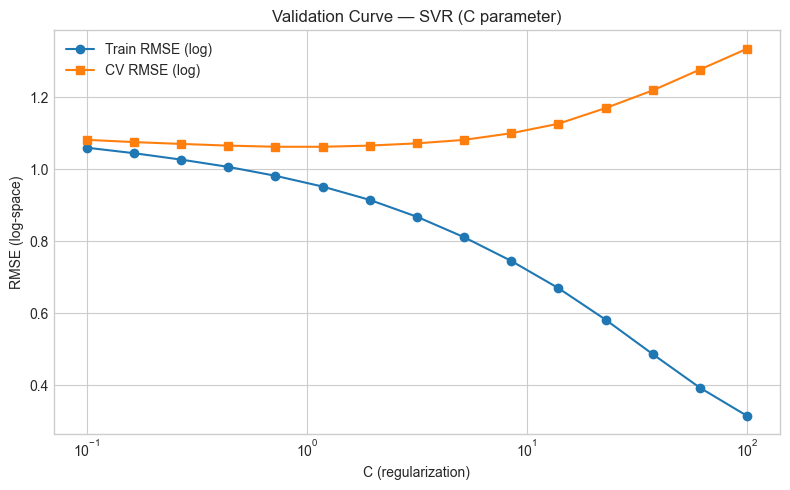

In [21]:
# Validation Curve: SVR C parameter 
from sklearn.model_selection import validation_curve

C_range = np.logspace(-1, 2, 15)
svr_vc_pipe = Pipeline([("scaler", RobustScaler()), ("model", SVR(kernel="rbf", epsilon=0.1))])

train_scores, val_scores = validation_curve(
    svr_vc_pipe, X_train, y_train_log,
    param_name="model__C", param_range=C_range,
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)

train_rmse = np.sqrt(-train_scores).mean(axis=1)
val_rmse_vc = np.sqrt(-val_scores).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(C_range, train_rmse, 'o-', label="Train RMSE (log)")
ax.semilogx(C_range, val_rmse_vc, 's-', label="CV RMSE (log)")
ax.set_xlabel("C (regularization)")
ax.set_ylabel("RMSE (log-space)")
ax.set_title("Validation Curve — SVR (C parameter)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Part 6: Final Model Evaluation & Diagnostics

### Best Model Selection

Based on validation RMSE comparison, I select the best-performing tuned model and evaluate it on the held-out internal test set to get an unbiased RMSE estimate.

This internal test set was never used during training, feature selection, or hyperparameter tuning — ensuring an honest generalization estimate.

In [22]:
# Select best model and evaluate on INTERNAL TEST SET
best_models_dict = {
    "RidgeCV": Pipeline([("scaler", RobustScaler()), ("model", Ridge(alpha=ridge_cv.alpha_))]),
    "LassoCV": Pipeline([("scaler", RobustScaler()), ("model", Lasso(alpha=lasso_cv.alpha_, max_iter=20000))]),
    "ElasticNetCV": Pipeline([("scaler", RobustScaler()), ("model", ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=20000))]),
    "KNN (tuned)": Pipeline([("scaler", RobustScaler()), ("model", KNeighborsRegressor(**{k.replace("model__", ""): v for k, v in knn_search.best_params_.items()}))]),
    "SVR (tuned)": svr_search.best_estimator_,
    "Stacking": stacking_pipe,
    "Bagging-SVR": bagging_pipe,
}

# Identify best by val RMSE
best_name = min(tuned_results, key=tuned_results.get)
print(f"Best model by validation RMSE: {best_name} (${tuned_results[best_name]:,.0f})")

# Fit best model on TRAIN data and evaluate on internal test
final_model = best_models_dict[best_name]
final_model.fit(X_train, y_train_log)

# Predict on internal test set
pred_test_internal_log = final_model.predict(X_test_internal)
pred_test_internal = np.expm1(pred_test_internal_log)

# Final unbiased RMSE
final_rmse = root_mean_squared_error(y_test_internal, pred_test_internal)
print(f"FINAL UNBIASED RMSE (internal test set): ${final_rmse:,.0f}")

# which observations cause the huge RMSE?
errors = (pred_test_internal - y_test_internal.values)
abs_errors = np.abs(errors)
squared_errors = errors ** 2

print(f"\nError Breakdown:")
print(f"Total test samples: {len(y_test_internal)}")
print(f"Median absolute error: ${np.median(abs_errors)}")
print(f"Mean absolute error: ${abs_errors.mean()}")
print(f"RMSE (all): ${final_rmse}")

# What if we remove top 5 worst predictions?
for n in [1, 3, 5, 10]:
    top_n_idx = np.argsort(squared_errors)[::-1][n:]
    rmse_without = np.sqrt(squared_errors[top_n_idx].mean())
    print(f"RMSE without top {n} worst: ${rmse_without}")

# Show the worst predictions
worst_idx = np.argsort(squared_errors)[::-1][:10]
print(f"\nTop 10 Worst Predictions:")
print(f"{'Actual'} {'Predicted'} {'Error'}")
for idx in worst_idx:
    print(f"${y_test_internal.values[idx]} ${pred_test_internal[idx]} ${errors[idx]}")

Best model by validation RMSE: SVR (tuned) ($77,769)
FINAL UNBIASED RMSE (internal test set): $33,364

Error Breakdown:
Total test samples: 473
Median absolute error: $14946.514048695855
Mean absolute error: $22166.983466680922
RMSE (all): $33363.705793994755
RMSE without top 1 worst: $29862.429795722073
RMSE without top 3 worst: $27686.699471952907
RMSE without top 5 worst: $27067.157489077166
RMSE without top 10 worst: $25899.96905611334

Top 10 Worst Predictions:
Actual Predicted Error
$384552.0 $59589.24499858993 $-324962.7550014101
$298267.0 $71981.92512558153 $-226285.07487441847
$133100.0 $36002.39151679443 $-97097.60848320558
$124358.0 $29965.10984548381 $-94392.8901545162
$156547.0 $64358.435200084576 $-92188.56479991542
$162306.0 $79331.45011105614 $-82974.54988894386
$153492.0 $71729.81407102683 $-81762.18592897317
$140475.0 $59794.01604128992 $-80680.98395871007
$1086.0 $79334.49941282869 $78248.49941282869
$123306.0 $45299.92887007486 $-78006.07112992514


### Diagnostic Plots
As we can see the model quite struggles with the very low earners and very high earners.

On 2nd graph I zoomed in a bit to not see only outliers and see the most of the data clearly on the plot.

The 3rd plot shows residuals that fan out (get wider) as predicted salary increases, rather than being evenly scattered around zero. This happens because we train in log-space but plot in dollars — a small log-space error becomes a much bigger dollar error at high salaries. This confirms the log transform is working correctly: the model treats percentage errors equally across all salary levels.

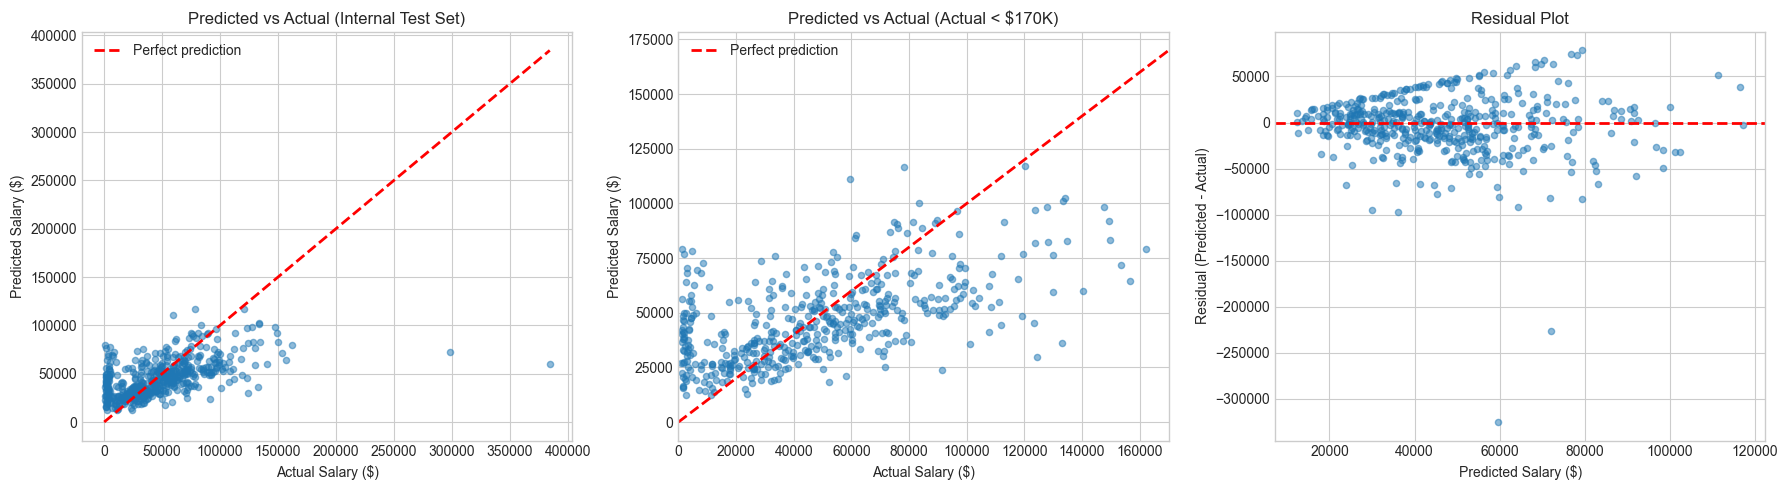

Residual mean: $-3,141 (should be ~0)
Residual std: $33,215
Max overestimate: $78,248
Max underestimate: $-324,963


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(y_test_internal, pred_test_internal, alpha=0.5, s=20)
max_val = max(y_test_internal.max(), pred_test_internal.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Salary ($)")
axes[0].set_ylabel("Predicted Salary ($)")
axes[0].set_title("Predicted vs Actual (Internal Test Set)")
axes[0].legend()

# Predicted vs Actual — zoomed (actual < $170K)
mask_zoom = y_test_internal < 170_000
axes[1].scatter(y_test_internal[mask_zoom], pred_test_internal[mask_zoom.values], alpha=0.5, s=20)
axes[1].plot([0, 170_000], [0, 170_000], 'r--', lw=2, label="Perfect prediction")
axes[1].set_xlabel("Actual Salary ($)")
axes[1].set_ylabel("Predicted Salary ($)")
axes[1].set_title("Predicted vs Actual (Actual < $170K)")
axes[1].set_xlim(0, 170_000)
axes[1].legend()

# Residual plot
residuals = pred_test_internal - y_test_internal.values
axes[2].scatter(pred_test_internal, residuals, alpha=0.5, s=20)
axes[2].axhline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel("Predicted Salary ($)")
axes[2].set_ylabel("Residual (Predicted - Actual)")
axes[2].set_title("Residual Plot")

plt.tight_layout()
plt.show()

# Residual statistics
print(f"Residual mean: ${residuals.mean():,.0f} (should be ~0)")
print(f"Residual std: ${residuals.std():,.0f}")
print(f"Max overestimate: ${residuals.max():,.0f}")
print(f"Max underestimate: ${residuals.min():,.0f}")

## Part 7: Competition Submission

For the final submission, I retrain the best model on **all** of train.csv (train + validation + internal test combined) to maximize the amount of training data. I then apply the identical preprocessing pipeline to test.csv and generate predictions.

For the submission, I do not cap the target — capping prevents predicting high earners correctly on unseen data. Instead, I train on the full uncapped log-transformed target.

In [24]:
#  FULL RETRAIN & SUBMISSION 
import re

# Reload and clean full training data (only remove clear errors)
df_full = pd.read_csv("data/train.csv")
df_full = df_full[df_full['annual.pay.usd'] >= 1000].copy()

y_full = df_full['annual.pay.usd']
X_full = df_full.drop(columns=['annual.pay.usd'])

# Log-transform target
y_full_log = np.log1p(y_full)

# Load competition test set
df_test = pd.read_csv("data/test.csv")
test_ids = df_test['id']
X_comp_test = df_test.drop(columns=['id'])

print(f"Full training: {X_full.shape[0]} rows")
print(f"Competition test: {X_comp_test.shape[0]} rows")

Full training: 2362 rows
Competition test: 628 rows


### Submission Preprocessing Pipeline

I apply the exact same preprocessing pipeline used during training to both the full training set and the competition test set. This ensures consistency and the model benefits from more training data.

In [25]:
import re
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression as LR_imp

# Domain knowledge column filter 
drop_cols = ['first.help.source', 'personal.os', 'comm.tools', 'dev.environments',
             'ai.sentiment', 'ai.trust', 'ai.complex.rating', 'ai.job.threat',
             'how.learned.coding', 'side.coding', 'job.satisfaction',
             'cloud.hosting', 'daily.search.time', 'people.manager']
X_full = X_full.drop(columns=[c for c in drop_cols if c in X_full.columns])
X_comp_test = X_comp_test.drop(columns=[c for c in drop_cols if c in X_comp_test.columns])

#  MissingIndicators for high-missing salary-relevant columns
for df_x in [X_full, X_comp_test]:
    df_x['experience_missing'] = df_x['experience.years'].isnull().astype(int)
    df_x['industry_missing'] = df_x['industry'].isnull().astype(int)
    df_x['daily_answer_missing'] = df_x['daily.answer.time'].isnull().astype(int)

#  Handling industry: fill NaN with "Missing" 
for df_x in [X_full, X_comp_test]:
    df_x['industry'] = df_x['industry'].fillna('Missing')

#  Handling daily.answer.time: ordinal with -1 for missing 
time_order = {"Less than 15 minutes a day": 0, "15-30 minutes a day": 1,
              "30-60 minutes a day": 2, "60-120 minutes a day": 3, "Over 120 minutes a day": 4}
for df_x in [X_full, X_comp_test]:
    df_x['daily.answer.time'] = df_x['daily.answer.time'].map(time_order).fillna(-1)

#  Handling experience.years: impute from coding.years.professional + coding.years.total 
exp_predictors_sub = ['coding.years.professional', 'coding.years.total']
mask_exp_full = (X_full['experience.years'].notna() &
                 X_full['coding.years.professional'].notna() &
                 X_full['coding.years.total'].notna())
exp_imp_sub = LR_imp()
exp_imp_sub.fit(X_full.loc[mask_exp_full, exp_predictors_sub],
                X_full.loc[mask_exp_full, 'experience.years'])
for df_x in [X_full, X_comp_test]:
    missing_exp = (df_x['experience.years'].isnull() &
                   df_x['coding.years.professional'].notna() &
                   df_x['coding.years.total'].notna())
    if missing_exp.any():
        df_x.loc[missing_exp, 'experience.years'] = exp_imp_sub.predict(
            df_x.loc[missing_exp, exp_predictors_sub])
    still_missing = df_x['experience.years'].isnull()
    if still_missing.any():
        df_x.loc[still_missing, 'experience.years'] = X_full.loc[mask_exp_full, 'experience.years'].median()

#  REGION TARGET ENCODING 
region_full = X_full['region'].copy()
region_comp = X_comp_test['region'].copy()

global_mean_sub = y_full_log.mean()
region_enc_full = pd.Series(index=X_full.index, dtype=float)
kf_sub = KFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, vl_idx in kf_sub.split(X_full):
    fold_means = y_full_log.iloc[tr_idx].groupby(region_full.iloc[tr_idx]).mean()
    region_enc_full.iloc[vl_idx] = region_full.iloc[vl_idx].map(fold_means).fillna(global_mean_sub)

full_region_means_sub = y_full_log.groupby(region_full).mean()
region_enc_comp = region_comp.map(full_region_means_sub).fillna(global_mean_sub)

X_full['region_target_enc'] = region_enc_full.values
X_comp_test['region_target_enc'] = region_enc_comp.values
X_full = X_full.drop(columns=['region'])
X_comp_test = X_comp_test.drop(columns=['region'])

#  Ordinal encoding 
age_order = {"18-24": 0, "25-34": 1, "35-44": 2, "45-54": 3, "55+": 4}
edu_order = {
    "Primary/elementary school": 0,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2,
    "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
    "Something else": 2
}
company_order = {
    "Just me - I am a freelancer, sole proprietor, etc.": 0,
    "2 to 9 employees": 1, "10 to 19 employees": 2,
    "20 to 99 employees": 3, "100 to 499 employees": 4,
    "500 to 999 employees": 5, "1,000 to 4,999 employees": 6,
    "5,000 to 9,999 employees": 7, "10,000 or more employees": 8,
    "I don\u2019t know": np.nan
}
influence_order = {"I have little or no influence": 0, "I have some influence": 1, "I have a great deal of influence": 2}

for df_x in [X_full, X_comp_test]:
    df_x["age.group"] = df_x["age.group"].map(age_order)
    df_x["education"] = df_x["education"].map(edu_order)
    df_x["company.size"] = df_x["company.size"].map(company_order)
    df_x["tech.purchase.influence"] = df_x["tech.purchase.influence"].map(influence_order)

# Binary encoding
for df_x in [X_full, X_comp_test]:
    df_x["is_dev"] = (df_x["is.dev.professional"] == "I am a developer by profession").astype(int)
    df_x.drop(columns=["is.dev.professional"], inplace=True)

#  Multi-select columns — count only (number of items selected) 
count_only_cols = ['prog.languages', 'databases', 'cloud.platforms',
                   'web.frameworks', 'other.tech', 'dev.tools',
                   'work.os', 'project.mgmt.tools', 'ai.search.tools', 'ai.tools.used']

for col in count_only_cols:
    if col not in X_full.columns:
        continue
    for df_x in [X_full, X_comp_test]:
        df_x[f"{col}__count"] = df_x[col].fillna('').str.split(';').apply(lambda x: len([i for i in x if i.strip()]))
        df_x.drop(columns=[col], inplace=True)

#  dev.role one-hot
dev_dummies_full = pd.get_dummies(X_full['dev.role'], prefix='dev_role')
dev_dummies_test = pd.get_dummies(X_comp_test['dev.role'], prefix='dev_role')
dev_dummies_test = dev_dummies_test.reindex(columns=dev_dummies_full.columns, fill_value=0)
X_full = pd.concat([X_full.drop(columns=['dev.role']), dev_dummies_full], axis=1)
X_comp_test = pd.concat([X_comp_test.drop(columns=['dev.role']), dev_dummies_test], axis=1)

#Nominal one-hot (including industry with "Missing" category) 
nominal_cols = ["employment.type", "work.location", "build.vs.buy", "uses.ai", "industry"]
nominal_cols = [c for c in nominal_cols if c in X_full.columns]
X_full = pd.get_dummies(X_full, columns=nominal_cols, drop_first=True)
X_comp_test = pd.get_dummies(X_comp_test, columns=nominal_cols, drop_first=True)
X_comp_test = X_comp_test.reindex(columns=X_full.columns, fill_value=0)

#  Missing value handling: drop rows from training, KNNImputer for test 
print(f"Full train before dropping NaN: {X_full.shape[0]} rows")
mask_full_complete = ~X_full.isnull().any(axis=1)
X_full = X_full[mask_full_complete].copy()
y_full_log = y_full_log[mask_full_complete].copy()
print(f"Full train after dropping NaN: {X_full.shape[0]} rows")

# Clean up column names, because I was getting an error with the KNNImputer about the dot in the columnn name
clean = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in X_full.columns]
X_full.columns = clean
X_comp_test.columns = clean

# KNNImputer for competition test
numeric_features_sub = ["coding_years_total", "coding_years_professional", "experience_years"]
ordinal_features_sub = ["age_group", "education", "company_size", "tech_purchase_influence", "daily_answer_time"]
impute_cols_sub = [c for c in numeric_features_sub + ordinal_features_sub if c in X_comp_test.columns and X_comp_test[c].isnull().any()]
if impute_cols_sub:
    knn_imp_sub = KNNImputer(n_neighbors=5)
    knn_imp_sub.fit(X_full[impute_cols_sub])
    X_comp_test[impute_cols_sub] = knn_imp_sub.transform(X_comp_test[impute_cols_sub])
X_comp_test = X_comp_test.fillna(0)

#  Winsorization 
numeric_features_clean = ["coding_years_total", "coding_years_professional", "experience_years"]
for col in numeric_features_clean:
    if col in X_full.columns:
        p1 = X_full[col].quantile(0.01)
        p99 = X_full[col].quantile(0.99)
        X_full[col] = X_full[col].clip(lower=p1, upper=p99)
        X_comp_test[col] = X_comp_test[col].clip(lower=p1, upper=p99)

# Interaction features
for df_x in [X_full, X_comp_test]:
    df_x["exp_professional_sq"] = df_x["coding_years_professional"] ** 2
    df_x["exp_years_sq"] = df_x["experience_years"] ** 2
    df_x["exp_x_company"] = df_x["coding_years_professional"] * df_x["company_size"]
    df_x["exp_x_education"] = df_x["coding_years_professional"] * df_x["education"]
    df_x["total_coding_x_company"] = df_x["coding_years_total"] * df_x["company_size"]
    df_x["exp_x_region"] = df_x["coding_years_professional"] * df_x["region_target_enc"]
    df_x["education_x_region"] = df_x["education"] * df_x["region_target_enc"]
    df_x["company_x_region"] = df_x["company_size"] * df_x["region_target_enc"]
    df_x["expyears_x_region"] = df_x["experience_years"] * df_x["region_target_enc"]

#  Feature selection 
vt_full = VarianceThreshold(threshold=0.01)
vt_full.fit(X_full)
mask_vt_full = vt_full.get_support()
X_full = X_full.loc[:, mask_vt_full]
X_comp_test = X_comp_test.loc[:, mask_vt_full]

# Mutual information filter — keep top 40
mi_full = mutual_info_regression(X_full, y_full_log, random_state=42, n_neighbors=5)
mi_df_full = pd.DataFrame({"feature": X_full.columns, "mi_score": mi_full}).sort_values("mi_score", ascending=False)

keep_feats_sub = mi_df_full.head(40)["feature"].tolist()

print(f"X_full: {X_full.shape}, X_comp_test: {X_comp_test.shape}")
print(f"\nFinal submission features: {X_full.shape[1]}")

X_comp_test = X_comp_test[keep_feats_sub]
X_full = X_full[keep_feats_sub]

Full train before dropping NaN: 2362 rows
Full train after dropping NaN: 2316 rows
X_full: (2316, 68), X_comp_test: (628, 68)

Final submission features: 68


### Final Model Training & Prediction

I train the best model (selected by validation RMSE) on all available training data (full train.csv after preprocessing) and generate predictions on the competition test set. Predictions are transformed back to original dollar scale via expm1 (inverse of log1p). Any negative predictions are clipped to $300 (minimum realistic salary).

In [26]:
# Train best model on ALL data and generate submission 
best_svr_params_sub = {k.replace("model__", ""): v for k, v in svr_search.best_params_.items()}
best_knn_params_sub = {k.replace("model__", ""): v for k, v in knn_search.best_params_.items()}

if "Stacking" in best_name:
    submission_model = Pipeline([("scaler", RobustScaler()), ("model", StackingRegressor(
        estimators=[
            ("ridge", Ridge(alpha=ridge_cv.alpha_)),
            ("svr", SVR(kernel="rbf", **best_svr_params_sub)),
            ("knn", KNeighborsRegressor(**best_knn_params_sub)),
            ("lasso", Lasso(alpha=lasso_cv.alpha_, max_iter=20000)),
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=5
    ))])
elif "Bagging" in best_name:
    submission_model = Pipeline([("scaler", RobustScaler()), ("model", BaggingRegressor(
        estimator=SVR(kernel="rbf", **best_svr_params_sub),
        n_estimators=30, random_state=42, n_jobs=-1
    ))])
elif "SVR" in best_name:
    submission_model = Pipeline([
        ("scaler", RobustScaler()),
        ("model", SVR(**best_svr_params_sub))
    ])
elif "KNN" in best_name:
    submission_model = Pipeline([
        ("scaler", RobustScaler()),
        ("model", KNeighborsRegressor(**best_knn_params_sub))
    ])
elif "Ridge" in best_name:
    submission_model = Pipeline([("scaler", RobustScaler()), ("model", Ridge(alpha=ridge_cv.alpha_))])
elif "Lasso" in best_name:
    submission_model = Pipeline([("scaler", RobustScaler()), ("model", Lasso(alpha=lasso_cv.alpha_, max_iter=20000))])
elif "Elastic" in best_name:
    submission_model = Pipeline([("scaler", RobustScaler()), ("model", ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=20000))])
else:
    submission_model = Pipeline([("scaler", RobustScaler()), ("model", LinearRegression())])

# Train on all data
submission_model.fit(X_full, y_full_log)

# Predict on competition test set
preds_log = submission_model.predict(X_comp_test)
preds = np.expm1(preds_log)

# Clip any negative predictions to a reasonable minimum
preds = np.clip(preds, 300, None)

# Create submission file
submission = pd.DataFrame({'id': test_ids, 'annual.pay.usd': preds})
submission.to_csv('data/submission_v2.csv', index=False)

print(f"Submission saved: data/submission_v2.csv")
print(f"Rows: {len(submission)}")
print(f"Prediction stats:")
print(f"Mean: ${preds.mean():,.0f}")
print(f"Median: ${np.median(preds):,.0f}")
print(f"Min: ${preds.min():,.0f}")
print(f"Max: ${preds.max():,.0f}")
print(f"\nBest model used: {best_name}")
print(f"Expected RMSE (from internal test): ${final_rmse:,.0f}")

submission.head(10)

Submission saved: data/submission_v2.csv
Rows: 628
Prediction stats:
Mean: $43,730
Median: $41,168
Min: $8,835
Max: $126,021

Best model used: SVR (tuned)
Expected RMSE (from internal test): $33,364


,id,annual.pay.usd
0,0,18683.498979
1,1,29959.349635
2,2,41676.828520
3,3,82540.915697
4,4,33872.679541
5,5,81452.145625
6,6,45000.124617
7,7,68718.599202
8,8,19720.614539
9,9,52233.702456
